# Prompt-Driven Exploration: a microwave walkthrough
A vision-language-action model (VLA) can produce very different robot behavior
when the same task is expressed in different words. **Prompt-Driven Exploration
(PDE)** uses this variation to find successful trajectories and learn from them.

PDE has two stages:

1. **Discover prompts with a vision-language model (VLM).** Keep the VLA weights
   fixed, collect rollouts, and ask a VLM to summarize behavior and propose new
   instructions. Evaluate the proposals against the original simulator goal and
   retain prompts with nonzero task success in a prompt pool.
2. **Train the VLA with that pool.** Run PPO with the fixed pool and an adaptive
   mixture of exploratory and original instructions. PDE's policy update uses
   likelihoods under both instructions, transferring useful behavior toward the
   original task prompt. Final task evaluation uses the original instruction.

This notebook introduces the first stage through **“close the microwave.”**
Watch recorded rollouts, compare instructions with a frozen pi0.5 policy, then
run one VLM proposal-and-evaluation cycle. The final section links to iterative
prompt discovery and RL training with the released code.

**Start with the saved examples below; no GPU or API key is needed to view them.**
For video playback controls, open the notebook in JupyterLab. GitHub provides a
static preview. To generate new rollouts, follow **Try prompt exploration** below.

[Project code](https://github.com/xinyunsunshine/PDE) ·
[Method and training commands](https://github.com/xinyunsunshine/PDE#1-discover-prompts-with-a-vlm)


## 1. Prompt wording changes behavior
Under the original instruction **“close the microwave,”** the policy reaches for
the mug instead of closing the door. Two alternative wordings elicit successful
door-closing behavior in the matched examples below:

- **“push on the microwave door until it shuts”** describes the physical action.
- **“shut the open appliance door”** refers to the target without the word “microwave.”

Only the instruction changes within each comparison. Policy weights, the
initial simulator state, and inference seed stay fixed. The simulator still
checks the original microwave-closing goal, regardless of the prompt used.
This is the motivation for PDE: language can expose useful behavior that the
original instruction does not reliably elicit.

These paper-motivated prompts were selected through simulator testing for this
walkthrough. The separate VLM example below demonstrates how feedback can guide
new proposals; it did not generate these two successful examples.

**Example settings:** public [RLinf pi0.5 LIBERO SFT checkpoint](https://huggingface.co/RLinf/RLinf-Pi05-LIBERO-SFT)
at revision `45ccfcc4e28634f1576ebf78cab0fbe2fd82432d`, initial-state index
`trial=1`, `seed=0`, `steps=480`, and `sampling_mode="train"` (exploration sampling
with frozen weights). Both alternatives succeeded in independent reruns;
the original prompt failed in both matched comparisons.

The examples are selected successes, not a success-rate estimate. Both wordings
failed on initial state 0. The [complete search record](microwave_prompt_search.json)
contains 55 completed search rollouts; four additional rollouts independently
confirmed the two comparisons. For the paper's aggregate results, see the paper
rather than these individual demonstrations.

The animations show simulator frames at 5 fps, with full 20-fps videos in the
cell outputs. **Left: original prompt. Right: alternative prompt.** Success is
the benchmark's `success_once` metric: the goal was reached during the episode.

### Describe the action: “push on the microwave door until it shuts”
![Original versus action-focused prompt](https://raw.githubusercontent.com/xinyunsunshine/PDE/main/notebooks/recorded/verified-working/comparison.gif)


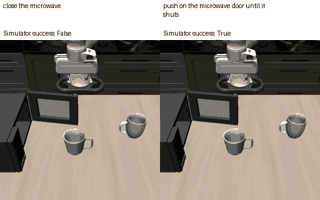

Same initial image: True
Settings: {'trial': 1, 'seed': 0, 'steps': 480, 'sampling_mode': 'train'}


In [1]:
from pathlib import Path
import json
cwd = Path.cwd().resolve()
NOTEBOOKS = next(p / "notebooks" for p in (cwd, *cwd.parents)
                 if (p / "notebooks/microwave_validation.json").is_file())
# Display simulator rollouts and their task-success labels
from IPython.display import HTML, Image, Video, display
import html

def show_comparison(directory, animated=True):
    report = json.loads((directory / "comparison.json").read_text())
    preview = directory / "notebook_preview.gif"
    if not preview.exists():
        preview = directory / "comparison.gif"
    if animated and preview.exists():
        display(Image(filename=str(preview), format="gif"))
    for index, result in enumerate(report["results"]):
        label = "Original prompt" if index == 0 else "Alternative prompt"
        display(HTML(f"<h4>{label}: {html.escape(result['prompt'])}</h4>"
                     f"<p>Simulator success: {result['success']}</p>"))
        display(Video(filename=str(directory / result["video"]), embed=True,
                      mimetype="video/mp4", width=512,
                      html_attributes="controls loop playsinline"))
    print("Same initial image:", report["results"][0]["initial_image_sha256"] == report["results"][1]["initial_image_sha256"])

show_comparison(NOTEBOOKS / "recorded/verified-working")
report = json.loads((NOTEBOOKS / "recorded/verified-working/comparison.json").read_text())
print("Settings:", {"trial": report["trial"], **{k: report["results"][1][k] for k in ["seed", "steps", "sampling_mode"]}})


### Change the reference: “shut the open appliance door”
This wording also succeeds in the selected state while the original instruction
fails. PDE evaluates candidate instructions by task success, so different
wordings can enter the same pool without changing the task's reward.

![Original versus appliance prompt](https://raw.githubusercontent.com/xinyunsunshine/PDE/main/notebooks/recorded/verified-working-appliance/comparison.gif)


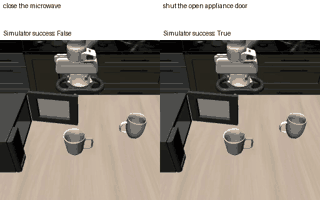

Same initial image: True
Completed search rollouts: 55
Successful search rollouts: 2
These are adaptively selected examples, not a success-rate estimate.


In [2]:
show_comparison(NOTEBOOKS / "recorded/verified-working-appliance")
search = json.loads((NOTEBOOKS / "microwave_prompt_search.json").read_text())
print("Completed search rollouts:", search["completed_rollouts"])
print("Successful search rollouts:", search["successful_rollouts"])
print("These are adaptively selected examples, not a success-rate estimate.")


## 2. VLM proposals need simulator feedback
A plausible instruction is not necessarily useful to a particular VLA. This
recorded example shows a failed original rollout, a manual rewrite, an actual
Qwen3-VL-2B-Instruct response, and a rollout using its first suggested prompt.
All three instructions fail in this example (`trial=0`, `seed=0`, `steps=240`,
evaluation sampling).

The VLM receives eight frames from the original rollout, summarizes the behavior,
and proposes alternative instructions. Its description is an interpretation;
**the simulator determines whether a proposal succeeds**. In full PDE discovery,
both successes and failures inform subsequent proposals, and only prompts with
nonzero measured task success are admitted to the pool. One VLM call and one
replay, as shown here, illustrate a single part of that iterative process.

The next cells display saved artifacts without running inference or making API
calls. GPU and checkpoint details are available in the
[execution record](microwave_validation.json).


In [3]:
record = json.loads((NOTEBOOKS / "recorded/rollouts/comparison.json").read_text())
print("Recorded feedback example:", {
    "task": record["results"][0]["canonical_prompt"],
    "trial": record["trial"],
    "seed": record["results"][0]["seed"],
    "steps": record["results"][0]["steps"],
    "sampling_mode": "eval",
})


Recorded feedback example: {'task': 'close the microwave', 'trial': 0, 'seed': 0, 'steps': 240, 'sampling_mode': 'eval'}


### Observe the failure
The original instruction and a manual rewrite both fail in this starting state.
Compare the robot's interaction with the mug and the microwave door.

![Original and manual-rewrite rollouts](https://raw.githubusercontent.com/xinyunsunshine/PDE/main/notebooks/recorded/rollouts/comparison.gif)


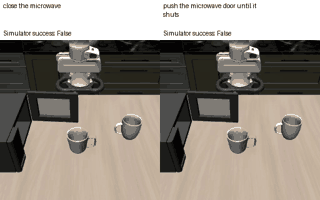

Same initial image: True


In [4]:
# Display simulator rollouts and their task-success labels
from IPython.display import HTML, Image, Video, display
import html

def show_comparison(directory, animated=True):
    report = json.loads((directory / "comparison.json").read_text())
    preview = directory / "notebook_preview.gif"
    if not preview.exists():
        preview = directory / "comparison.gif"
    if animated and preview.exists():
        display(Image(filename=str(preview), format="gif"))
    for index, result in enumerate(report["results"]):
        label = "Original prompt" if index == 0 else "Alternative prompt"
        display(HTML(f"<h4>{label}: {html.escape(result['prompt'])}</h4>"
                     f"<p>Simulator success: {result['success']}</p>"))
        display(Video(filename=str(directory / result["video"]), embed=True,
                      mimetype="video/mp4", width=512,
                      html_attributes="controls loop playsinline"))
    print("Same initial image:", report["results"][0]["initial_image_sha256"] == report["results"][1]["initial_image_sha256"])

show_comparison(NOTEBOOKS / "recorded/rollouts")


### Read the VLM feedback
The following JSON is the response from Qwen3-VL-2B-Instruct for the original
rollout above. Notice the distinction between its behavior summary, its proposed
instructions, and the simulator's recorded success label.


In [5]:
recorded_feedback = json.loads((NOTEBOOKS / "recorded/rollouts/vlm_feedback.json").read_text())
print(json.dumps(recorded_feedback, indent=2))


{
  "provider": "local_qwen",
  "model": "Qwen/Qwen3-VL-2B-Instruct",
  "summary": "The robot attempted to close the microwave by placing a mug inside it, but failed to do so as it was not properly aligned and the microwave door did not close correctly.",
  "new_prompts": [
    "close the microwave door properly",
    "ensure the microwave door is fully closed",
    "close the microwave without a mug inside"
  ],
  "simulator_success": false
}


### Evaluate the first VLM proposal
The first proposed instruction, **“close the microwave door properly,”** also
fails here. This is feedback for another discovery round, rather than a prompt
to admit as successful based on its wording alone.

![Original and VLM-proposal rollouts](https://raw.githubusercontent.com/xinyunsunshine/PDE/main/notebooks/recorded/vlm-rollouts/comparison.gif)


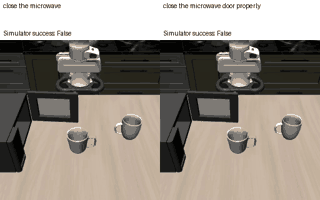

Same initial image: True


In [6]:
show_comparison(NOTEBOOKS / "recorded/vlm-rollouts")


## 3. Try prompt exploration
Run the following cells to compare your own instructions and request new VLM
proposals. Start with the provided example settings, then change one variable
at a time: the instruction, initial-state index (`trial`), or inference seed.

**Environment:** JupyterLab on Linux with one native-BF16 NVIDIA GPU (A100, L4,
or H100), at least 32 GB host RAM recommended, and 40 GB free disk. T4 GPUs are
not supported by this BF16 path. Install the system libraries listed in the
[setup instructions](https://github.com/xinyunsunshine/PDE#interactive-microwave-demo)
first. The installer creates a separate Python 3.11 inference environment;
the notebook kernel does not need a restart. Setup downloads several GB.

The examples use the public RLinf pi0.5 checkpoint linked above. A compatible
local checkpoint can be supplied instead. This walkthrough runs frozen-policy
inference on one environment; PPO training is launched separately. The optional
VLM step uses the OpenAI API or a separately hosted Qwen endpoint.


In [ ]:
# 1. Locate PDE and choose a workspace
import os
import sys
import json
import subprocess
from pathlib import Path

# Leave blank when launching Jupyter from PDE or its notebooks directory.
repo_directory = ""
workspace_directory = "~/pde-demo"
cwd = Path.cwd().resolve()
REPO = Path(repo_directory).expanduser().resolve() if repo_directory else next(
    (p for p in (cwd, *cwd.parents) if (p / "pde/demo.py").is_file()),
    Path.home() / "PDE",
)
WORKSPACE = Path(workspace_directory).expanduser().resolve()
WORKSPACE.mkdir(parents=True, exist_ok=True)
if not REPO.exists():
    subprocess.run(["git", "clone", "--recurse-submodules", "https://github.com/xinyunsunshine/PDE.git", str(REPO)], check=True)
if not (REPO / "pde/demo.py").is_file():
    raise ValueError("Set repo_directory to your PDE checkout")
subprocess.run(["git", "submodule", "update", "--init", "--recursive"], cwd=REPO, check=True)
subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], check=True)
capabilities = subprocess.check_output(["nvidia-smi", "--query-gpu=compute_cap", "--format=csv,noheader"], text=True)
if float(capabilities.strip().splitlines()[0]) < 8.0:
    raise RuntimeError("This pi0.5 path requires native BF16 (A100, L4 or H100)")
print("PDE revision:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip())


In [ ]:
# 2. Install the isolated Python 3.11 inference environment
# Keep the notebook kernel unchanged. No restart is needed.
# Install Linux EGL/GL libraries and ffmpeg beforehand (see README).
install_env = dict(os.environ, PDE_DEMO_ENV=str(WORKSPACE / "env"),
                   PDE_DEMO_DEPS=str(WORKSPACE / "deps"))
subprocess.run(["bash", "scripts/install_demo.sh"], env=install_env, cwd=REPO, check=True)
PYTHON = str(WORKSPACE / "env/bin/python")
os.environ.update({"MUJOCO_GL": "egl", "PYOPENGL_PLATFORM": "egl",
                   "JAX_PLATFORMS": "cpu", "LIBERO_TYPE": "standard"})

def run_demo(*args):
    subprocess.run([PYTHON, "-m", "pde.demo", *map(str, args)], cwd=REPO, check=True)

subprocess.run([PYTHON, "-c", "import torch; print(torch.cuda.get_device_name()); assert torch.cuda.get_device_capability()[0] >= 8, 'Use a native-BF16 GPU such as A100, L4 or H100'"], check=True)


In [ ]:
# 3. Choose and download the VLA checkpoint
checkpoint_id = "RLinf/RLinf-Pi05-LIBERO-SFT"
checkpoint_revision = "45ccfcc4e28634f1576ebf78cab0fbe2fd82432d"
# A compatible local checkpoint directory can be supplied instead of downloading.
local_checkpoint = ""
CHECKPOINT = str(Path(local_checkpoint).expanduser()) if local_checkpoint else str(WORKSPACE / "checkpoint")
if not local_checkpoint:
    script = """from huggingface_hub import HfApi, snapshot_download
from pathlib import Path
import json, sys
repo, revision, destination = sys.argv[1:]
sha = HfApi().model_info(repo, revision=revision, token=False).sha
snapshot_download(repo_id=repo, revision=sha, local_dir=destination, token=False)
Path(destination, 'demo_source.json').write_text(json.dumps({'repo_id': repo, 'revision': sha}))
print('Checkpoint revision:', sha)
"""
    subprocess.run([PYTHON, "-c", script, checkpoint_id, checkpoint_revision, CHECKPOINT], check=True)
print("Using checkpoint:", CHECKPOINT)


### Compare an instruction against the original goal
Choose one of the example prompts or set `custom_prompt` to your own instruction.
Run the comparison and display cells again after each edit. The policy is loaded
once per pair and each rollout starts in a fresh simulator with the same saved
state and seed.

The default `trial=1`, `seed=0`, and 480-step horizon reproduce the selected
successful examples. `sampling_mode="train"` enables PDE's exploration noise;
it does **not** update the model's weights. Use `"eval"` to try ODE inference.
Both prompts always use the same sampling mode. The simulator's original
microwave-closing condition supplies the success label.

When comparing prompts beyond this illustration, evaluate across multiple
initial states and seeds. A success on one selected trial does not establish
a prompt's overall reliability.


In [ ]:
# 4. Write a prompt and run the comparison
working_prompts = [
    "push on the microwave door until it shuts",
    "shut the open appliance door",
]
custom_prompt = working_prompts[0]  # Choose the second example or enter your own text.
# "train" adds PDE exploration noise; weights remain frozen in both modes.
sampling_mode = "train"
seed = 0
trial = 1
steps = 480
OUTPUT = WORKSPACE / "microwave-demo"
run_demo("compare", "--checkpoint", CHECKPOINT, "--prompt", custom_prompt,
         "--seed", seed, "--trial", trial, "--steps", steps,
         "--sampling-mode", sampling_mode, "--output", OUTPUT)


In [ ]:
# Display simulator rollouts and their task-success labels
from IPython.display import HTML, Image, Video, display
import html

def show_comparison(directory, animated=True):
    report = json.loads((directory / "comparison.json").read_text())
    preview = directory / "notebook_preview.gif"
    if not preview.exists():
        preview = directory / "comparison.gif"
    if animated and preview.exists():
        display(Image(filename=str(preview), format="gif"))
    for index, result in enumerate(report["results"]):
        label = "Original prompt" if index == 0 else "Alternative prompt"
        display(HTML(f"<h4>{label}: {html.escape(result['prompt'])}</h4>"
                     f"<p>Simulator success: {result['success']}</p>"))
        display(Video(filename=str(directory / result["video"]), embed=True,
                      mimetype="video/mp4", width=512,
                      html_attributes="controls loop playsinline"))
    print("Same initial image:", report["results"][0]["initial_image_sha256"] == report["results"][1]["initial_image_sha256"])

show_comparison(OUTPUT)


### Ask a VLM to propose alternatives
This step makes two requests: a summary of eight frames from the original
rollout, followed by three candidate instructions based on that summary.
Inspect the returned text, then use the next cell to evaluate a proposal with
the VLA. The VLM supplies ideas; the simulator supplies the success signal.

Set `provider="openai"` for the OpenAI API, or `provider="local_qwen"` for a
reachable OpenAI-compatible Qwen server. For Qwen, set `vlm_model` to the served
model ID and `qwen_base_url` to its endpoint, including `/v1`. Host the VLM
separately to keep the local GPU available for the VLA.

Set `OPENAI_API_KEY` or `QWEN_API_KEY` in the environment, or use the hidden key
prompt. Keys are not stored in the notebook or result files. OpenAI requests
send the sampled frames to the API and incur API usage.


In [ ]:
# 6. Call the VLM and display its output
provider = "openai"
vlm_model = "gpt-4.1"
qwen_base_url = ""
# For local_qwen, set the server's model ID above (e.g. Qwen/Qwen3-VL-8B-Instruct).
from getpass import getpass
key_name = "OPENAI_API_KEY" if provider == "openai" else "QWEN_API_KEY"
api_key = os.environ.get(key_name) or getpass(
    f"{key_name} (local Qwen without authentication: leave blank): "
)
if provider == "openai" and not api_key:
    raise ValueError("An OpenAI API key is required for this optional step")
if provider == "local_qwen" and not qwen_base_url:
    raise ValueError("Enter the reachable Qwen server URL, including /v1")
args = ["feedback", "--output", OUTPUT, "--provider", provider, "--model", vlm_model]
if provider == "local_qwen":
    args += ["--base-url", qwen_base_url]
previous_key = os.environ.get(key_name)
try:
    if api_key:
        os.environ[key_name] = api_key
    else:
        os.environ.pop(key_name, None)
    run_demo(*args)
finally:
    if previous_key is None:
        os.environ.pop(key_name, None)
    else:
        os.environ[key_name] = previous_key
    del api_key
feedback = json.loads((OUTPUT / "vlm_feedback.json").read_text())
print("VLM summary:\n", feedback["summary"])
print("Suggested prompts:")
for i, prompt in enumerate(feedback["new_prompts"]):
    print(f"{i}: {prompt}")
print("Simulator success (ground truth):", feedback["simulator_success"])


In [ ]:
# 7. Try a VLM suggestion against the original prompt
suggestion_index = 0
if not 0 <= suggestion_index < len(feedback["new_prompts"]):
    raise ValueError("Choose an index printed in the previous cell")
suggested_prompt = feedback["new_prompts"][suggestion_index]
VLM_OUTPUT = WORKSPACE / "microwave-vlm-demo"
run_demo("compare", "--checkpoint", CHECKPOINT, "--prompt", suggested_prompt,
         "--seed", seed, "--trial", trial, "--steps", steps,
         "--sampling-mode", sampling_mode, "--output", VLM_OUTPUT)
show_comparison(VLM_OUTPUT)


## 4. From this example to the full method
The notebook demonstrates prompt-conditioned behavior and one VLM feedback
cycle. Full PDE uses repeated proposal-and-evaluation rounds to build a prompt
pool, then trains a policy with that pool.

1. **Build a pool for each task.** Follow
   [Discover prompts with a VLM](https://github.com/xinyunsunshine/PDE#1-discover-prompts-with-a-vlm)
   to run `python -m pde.search` with a frozen checkpoint and either VLM provider.
   Evaluate candidates over multiple rollouts; unsuccessful candidates still
   contribute feedback, while only successful ones enter the admitted pool.
2. **Train with the frozen pools.** Follow
   [Train with frozen prompt pools](https://github.com/xinyunsunshine/PDE#2-train-with-frozen-prompt-pools)
   to run `python -m pde.train`. PPO samples exploratory and original instructions,
   and an adaptive schedule shifts training toward the original instruction as
   its success improves. PDE's update combines current-policy likelihoods under
   the sampled and original prompts. Training makes no VLM calls.
3. **Evaluate the learned policy under the original instruction.** This measures
   whether training transferred the discovered behavior to the task prompt used
   at deployment, rather than only improving performance under a chosen rewrite.

The training configuration and resource requirements are separate from this
single-GPU inference demo. The saved notebook rollouts do not demonstrate an
RL-trained policy or reproduce the paper's aggregate training results.

### Save and inspect experiments
New videos, sampled frames, prompts, success labels, and seeds are saved in
`WORKSPACE / "microwave-demo"` and `WORKSPACE / "microwave-vlm-demo"`. Save the
notebook to retain displayed outputs, and keep these directories for the
underlying artifacts. The installed package versions are recorded in
`WORKSPACE / "env/installed-requirements.txt"`.

The recorded runs used an H100 GPU. Consult the [execution record](microwave_validation.json)
for environment details and validation limits, and the [prompt search record](microwave_prompt_search.json)
for all completed candidate evaluations used to select the examples.

[Code and citation](https://github.com/xinyunsunshine/PDE) ·
[RLinf](https://github.com/RLinf/RLinf)
